# 📊 Análisis Completo de Sets (Incluyendo Runs 'BAD')

Este notebook ejecuta un análisis exhaustivo de **todos los calibration sets** aplicando los filtros correctos:

## 🔍 Filtros Aplicados:

1. ✅ **CalibSetNumber**: Solo valores enteros (ej: 3.0 válido, 3.5 inválido)
2. ✅ **Filename**: Excluye runs con `_pre`, `_st`, `lar` en el nombre
3. ✅ **Liquid Media**: Solo runs con `LN2` (excluye LAr)
4. ⚙️ **Selection**: Incluye/excluye runs marcados como `'BAD'` (configurable)
5. ✅ **Mínimo de runs**: Solo sets con ≥4 runs **disponibles** en el logfile

---

## ⚠️ IMPORTANTE: ¿Qué significa "≥4 runs disponibles"?

**"Runs disponibles"** = Filas en el LogFile que pasan los filtros (aunque estén marcadas como 'BAD')

**NO significa** que todos esos runs tengan datos de temperatura válidos.

### Ejemplo (Set 3):
- ✅ **10 runs disponibles** en logfile (6 BAD + 4 GOOD)
- ⚠️  **Run 5 falla** al calcular offsets ("No data in requested time window")
- ✅ **Set 3 se procesa exitosamente** con los 9 runs restantes (incluidos runs 7,8,9,10 que son válidos)

**Nota**: El código ahora es robusto y continúa procesando un set aunque algunos runs individuales fallen.

---

## 📈 Outputs Generados:

- `runs_per_set.png` — Gráfico de barras: número de runs por set
- `repeatability_set_X/` — Subdirectorios con plots de cada set (solo PNGs, sin CSVs/Excel)
- Estadísticas de filtrado en consola


In [1]:
# Celda 1: Setup - Imports y configuración de paths
import sys
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt

# Configurar path al repositorio
repo_root = Path('../..').resolve()
sys.path.insert(0, str(repo_root))

print(f'📁 Repo root: {repo_root}')

from RTD_Calibration_VGP.src.logfile import Logfile
from RTD_Calibration_VGP.src.set import Set
from RTD_Calibration_VGP.src.run import Run

print('✅ Módulos importados correctamente')

📁 Repo root: /Users/vicky/Desktop/rtd-calibration-ana
✅ Módulos importados correctamente


In [2]:
# Celda 2: Cargar y explorar el logfile
logfile_path = repo_root / 'RTD_Calibration_VGP' / 'data' / 'LogFile.csv'

if not logfile_path.exists():
    raise FileNotFoundError(f'❌ LogFile no encontrado: {logfile_path}')

lf = Logfile(str(logfile_path))
df_original = lf.log_file.copy()

print(f'📊 LogFile cargado: {len(df_original)} filas totales')
print(f'\n🔍 Columnas disponibles:')
for i, col in enumerate(df_original.columns, 1):
    print(f'  {i}. {col}')

print(f'\n📈 Distribución de Liquid Media:')
print(df_original['Liquid Media'].value_counts())

print(f'\n📋 Distribución de Selection:')
print(df_original['Selection'].value_counts())

CSV file loaded successfully from '/Users/vicky/Desktop/rtd-calibration-ana/RTD_Calibration_VGP/data/LogFile.csv'.
📊 LogFile cargado: 792 filas totales

🔍 Columnas disponibles:
  1. Filename
  2. Selection
  3. Liquid Media
  4. Type
  5. CalibSetNumber
  6. Date
  7. StartTime
  8. HeatFinTime
  9. FinTime
  10. REF1_ID
  11. REF2_ID
  12. REF1_CHAN
  13. REF2_CHAN
  14. N_Ref1
  15. N_Ref2
  16. S1
  17. S2
  18. S3
  19. S4
  20. S5
  21. S6
  22. S7
  23. S8
  24. S9
  25. S10
  26. S11
  27. S12
  28. S13
  29. S14
  30. S15
  31. S16
  32. S17
  33. S18
  34. S19
  35. S20
  36. BOARD
  37. N_Run
  38. Samples
  39. SamplingRate
  40. SampleMode
  41. Comments
  42. General Comments
  43. Unnamed: 42

📈 Distribución de Liquid Media:
Liquid Media
LN2    703
LAr      6
Name: count, dtype: int64

📋 Distribución de Selection:
Selection
GOOD    166
BAD      92
TRUE      1
Name: count, dtype: int64


---
## ⚙️ Configuración del Análisis

Aquí puedes configurar los filtros y parámetros del análisis.

In [3]:
# Celda 3: Configuración de filtros
# ===========================================
# PARÁMETROS CONFIGURABLES
# ===========================================

# ¿Incluir runs marcados como 'BAD'?
INCLUDE_BAD_RUNS = True  # Cambiar a False para excluir

# Directorio de salida
OUTPUT_DIR = 'outputs/analysis_all_sets_LN2_with_bad' if INCLUDE_BAD_RUNS else 'outputs/analysis_all_sets_LN2_no_bad'

# Mínimo de runs por set (recomendado: 4)
MIN_RUNS_PER_SET = 4

# Liquid media a incluir
LIQUID_MEDIA_FILTER = 'LN2'  # Cambiar a 'LAr' o None para incluir todo

print('🎯 CONFIGURACIÓN DEL ANÁLISIS')
print('=' * 50)
print(f'Incluir runs BAD:        {INCLUDE_BAD_RUNS}')
print(f'Liquid Media:            {LIQUID_MEDIA_FILTER}')
print(f'Mínimo runs por set:     {MIN_RUNS_PER_SET}')
print(f'Directorio de salida:    {OUTPUT_DIR}')
print('=' * 50)

🎯 CONFIGURACIÓN DEL ANÁLISIS
Incluir runs BAD:        True
Liquid Media:            LN2
Mínimo runs por set:     4
Directorio de salida:    outputs/analysis_all_sets_LN2_with_bad


---
## 🔍 Aplicación de Filtros y Análisis Exploratorio

In [4]:
# Celda 4: Aplicar filtros manualmente para análisis exploratorio
df_filtered = df_original.copy()

print('🔍 APLICANDO FILTROS...\n')
print(f'Filas iniciales: {len(df_filtered)}')

# Filtro 1: Liquid Media
if LIQUID_MEDIA_FILTER:
    before = len(df_filtered)
    df_filtered = df_filtered[df_filtered['Liquid Media'] == LIQUID_MEDIA_FILTER]
    after = len(df_filtered)
    print(f'✅ Filtro Liquid Media = {LIQUID_MEDIA_FILTER}: {before} → {after} ({before - after} excluidas)')

# Filtro 2: CalibSetNumber entero
before = len(df_filtered)
df_filtered['CalibSetNumber'] = pd.to_numeric(df_filtered['CalibSetNumber'], errors='coerce')
df_filtered = df_filtered[df_filtered['CalibSetNumber'].notna()]
df_filtered = df_filtered[df_filtered['CalibSetNumber'] % 1 == 0]
after = len(df_filtered)
print(f'✅ Filtro CalibSetNumber entero: {before} → {after} ({before - after} excluidas)')

# Filtro 3: Excluir filenames con _pre, _st, lar
before = len(df_filtered)
df_filtered = df_filtered[~df_filtered['Filename'].str.contains('_pre', case=False, na=False)]
df_filtered = df_filtered[~df_filtered['Filename'].str.contains('_st', case=False, na=False)]
df_filtered = df_filtered[~df_filtered['Filename'].str.contains('lar', case=False, na=False)]
after = len(df_filtered)
print(f'✅ Filtro Filename (_pre, _st, lar): {before} → {after} ({before - after} excluidas)')

# Filtro 4: Selection = 'BAD' (opcional)
if not INCLUDE_BAD_RUNS:
    before = len(df_filtered)
    df_filtered = df_filtered[df_filtered['Selection'] != 'BAD']
    after = len(df_filtered)
    print(f'✅ Filtro Selection != BAD: {before} → {after} ({before - after} excluidas)')
else:
    bad_count = (df_filtered['Selection'] == 'BAD').sum()
    print(f'ℹ️  Manteniendo runs BAD: {bad_count} filas')

print(f'\n📊 FILAS FINALES DESPUÉS DE FILTROS: {len(df_filtered)}')

# Agrupar por CalibSetNumber
counts = df_filtered.groupby('CalibSetNumber').size().sort_index()
sets_with_4_plus = counts[counts >= MIN_RUNS_PER_SET]

print(f'\n📈 SETS CON ≥{MIN_RUNS_PER_SET} RUNS: {len(sets_with_4_plus)}')
print(f'IDs: {sorted([int(x) for x in sets_with_4_plus.index])}')

🔍 APLICANDO FILTROS...

Filas iniciales: 792
✅ Filtro Liquid Media = LN2: 792 → 703 (89 excluidas)
✅ Filtro CalibSetNumber entero: 703 → 652 (51 excluidas)
✅ Filtro Filename (_pre, _st, lar): 652 → 321 (331 excluidas)
ℹ️  Manteniendo runs BAD: 81 filas

📊 FILAS FINALES DESPUÉS DE FILTROS: 321

📈 SETS CON ≥4 RUNS: 59
IDs: [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50, 51, 52, 53, 54, 55, 57, 58, 59, 60]


---
## 📊 Visualización: Runs por Set

✅ Gráfico guardado: outputs/analysis_all_sets_LN2_with_bad/runs_per_set_filtered.png


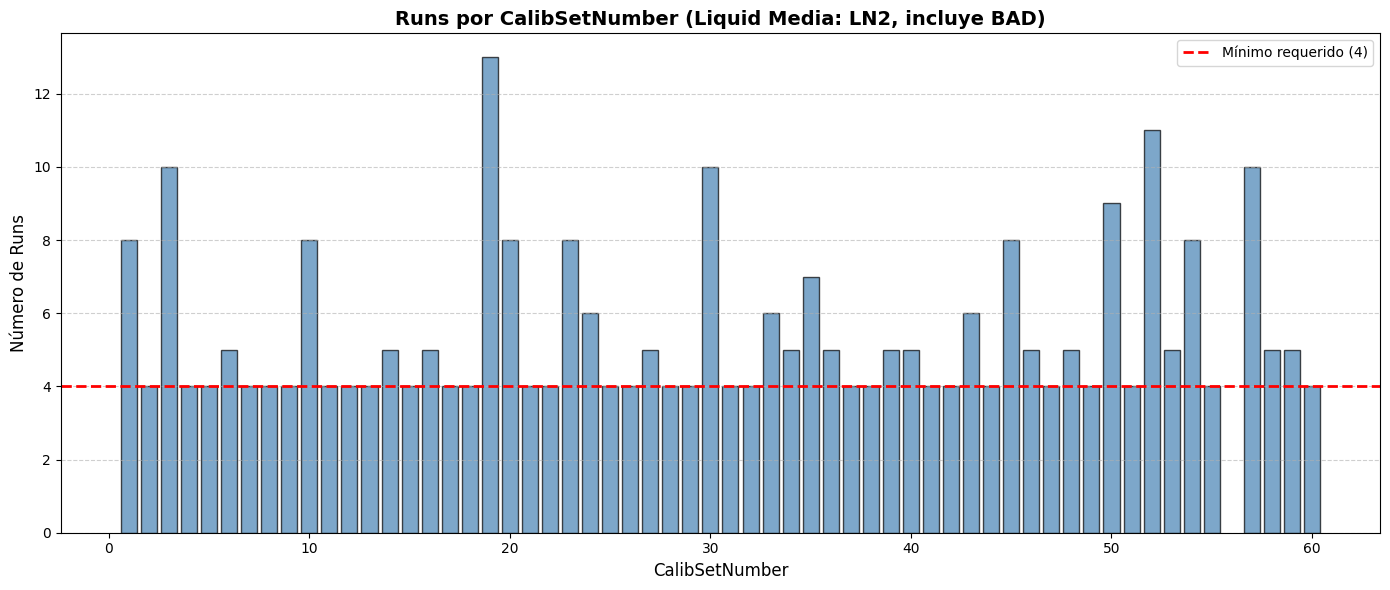

In [5]:
# Celda 5: Gráfico de barras - Runs por CalibSetNumber
plt.figure(figsize=(14, 6))
plt.bar([int(x) for x in counts.index], counts.values, color='steelblue', alpha=0.7, edgecolor='black')
plt.axhline(y=MIN_RUNS_PER_SET, color='red', linestyle='--', linewidth=2, label=f'Mínimo requerido ({MIN_RUNS_PER_SET})')
plt.xlabel('CalibSetNumber', fontsize=12)
plt.ylabel('Número de Runs', fontsize=12)

title = f'Runs por CalibSetNumber (Liquid Media: {LIQUID_MEDIA_FILTER}'
if INCLUDE_BAD_RUNS:
    title += ', incluye BAD)'
else:
    title += ', excluye BAD)'
plt.title(title, fontsize=14, fontweight='bold')

plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.legend()
plt.tight_layout()

# Guardar
Path(OUTPUT_DIR).mkdir(parents=True, exist_ok=True)
output_path = Path(OUTPUT_DIR) / 'runs_per_set_filtered.png'
plt.savefig(output_path, dpi=150)
print(f'✅ Gráfico guardado: {output_path}')
plt.show()

---
## 🔧 Función Mejorada: Análisis con Filtro de Liquid Media

Esta función extiende `plot_runs_vs_set_and_repeatability()` añadiendo el filtro de `Liquid Media`.

In [9]:
# Celda 6: Definir función mejorada con filtro LN2
import os

def analyze_all_sets_with_filters(
    set_instance,
    output_dir='analysis_output',
    include_bad=True,
    liquid_media='LN2',
    min_runs=4
):
    """
    Análisis completo de sets con filtros mejorados.
    
    Filtros aplicados:
    - CalibSetNumber: Solo enteros
    - Filename: Excluye _pre, _st, lar
    - Liquid Media: Filtra por tipo de líquido (LN2, LAr, etc.)
    - Selection: Incluye/excluye BAD según parámetro
    - Mínimo de runs: Solo procesa sets con ≥min_runs DISPONIBLES (incluso si son BAD)
    
    IMPORTANTE: "≥min_runs" se refiere a runs DISPONIBLES en el logfile después 
    de filtros (aunque sean BAD), NO a runs con datos válidos procesables.
    Algunos runs pueden fallar al cargar datos de temperatura.
    """
    print('\n' + '='*60)
    print('🚀 INICIANDO ANÁLISIS CON FILTROS MEJORADOS')
    print('='*60)
    
    logfile = set_instance.logfile.copy()
    
    # Filtro 1: Liquid Media
    if liquid_media:
        before = len(logfile)
        logfile = logfile[logfile['Liquid Media'] == liquid_media]
        print(f'✅ Filtro Liquid Media = {liquid_media}: {before} → {len(logfile)}')
    
    # Filtro 2: CalibSetNumber entero
    logfile['CalibSetNumber'] = pd.to_numeric(logfile['CalibSetNumber'], errors='coerce')
    logfile = logfile[logfile['CalibSetNumber'].notna()]
    integer_mask = logfile['CalibSetNumber'] % 1 == 0
    logfile = logfile[integer_mask]
    
    # Filtro 3: Excluir _pre, _st, lar
    logfile = logfile[~logfile['Filename'].str.contains('_pre', case=False, na=False)]
    logfile = logfile[~logfile['Filename'].str.contains('_st', case=False, na=False)]
    logfile = logfile[~logfile['Filename'].str.contains('lar', case=False, na=False)]
    
    # Filtro 4: BAD (opcional)
    if not include_bad:
        before = len(logfile)
        logfile = logfile[logfile['Selection'] != 'BAD']
        print(f'✅ Filtro Selection != BAD: {before} → {len(logfile)}')
    else:
        bad_count = (logfile['Selection'] == 'BAD').sum()
        print(f'ℹ️  Manteniendo {bad_count} runs BAD')
    
    # Contar runs por set
    counts = logfile.groupby('CalibSetNumber').size().sort_index()
    large_sets = [int(k) for k, v in counts.items() if v >= min_runs]
    
    print(f'\n📊 RESUMEN (runs DISPONIBLES en logfile):')
    print(f'  - Sets con ≥{min_runs} runs disponibles: {len(large_sets)}')
    print(f'  - IDs: {large_sets}')
    print(f'\nℹ️  NOTA: Algunos runs pueden fallar al cargar archivos de temperatura.')
    
    if not large_sets:
        print('⚠️  No hay sets elegibles. Terminando.')
        return
    
    # Crear directorio de salida
    os.makedirs(output_dir, exist_ok=True)
    
    # Procesar cada set
    original_runs = getattr(set_instance, 'runs_by_set', {}).copy()
    
    successful_sets = 0
    failed_sets = []
    
    try:
        for cs in large_sets:
            print(f'\n{"─"*60}')
            print(f'📦 Procesando Set {cs} ({counts.loc[float(cs)]} runs disponibles en logfile)')
            print(f'{"─"*60}')
            
            rows = logfile[logfile['CalibSetNumber'] == float(cs)]
            
            temp_runs = {}
            failed_loads = 0
            for _, row in rows.iterrows():
                fname = row['Filename']
                selection = row['Selection']
                try:
                    r = Run(fname, set_instance.logfile)
                    r.associate_sensors()
                    
                    # Aplicar filter_faulty_channels
                    faulty = r.filter_faulty_channels()
                    if faulty:
                        print(f'  ⚠️  {fname} [{selection}]: {len(faulty)} canales defectuosos')
                    
                    temp_runs[fname] = r
                    print(f'  ✅ {fname} [{selection}]: cargado correctamente')
                except Exception as e:
                    failed_loads += 1
                    print(f'  ❌ {fname} [{selection}]: Error - {str(e)[:80]}')
            
            print(f'\n  📊 Resultado: {len(temp_runs)}/{counts.loc[float(cs)]} runs cargados exitosamente')
            
            if len(temp_runs) < min_runs:
                print(f'  ⚠️  Solo {len(temp_runs)} runs con datos válidos (mínimo {min_runs})')
                print(f'  ⏭️  Saltando set {cs}')
                failed_sets.append(cs)
                continue
            
            # Ejecutar offset_repeatability para este set
            set_instance.runs_by_set = {float(cs): temp_runs}
            set_save_dir = os.path.join(output_dir, f'repeatability_set_{cs}')
            
            try:
                # Primero calcular offsets y RMS
                set_instance.calculate_offsets_and_rms(selected_sets=[float(cs)])
                
                # Luego generar plots de repeatability (SIN CSVs ni Excel)
                set_instance.offset_repeatability(
                    selected_sets=[float(cs)],
                    ref=2,
                    save_dir=set_save_dir,
                    write_csv=False,      # ← DESACTIVADO
                    write_excel=False     # ← DESACTIVADO
                )
                print(f'  ✅ Set {cs} procesado. Plots en: {set_save_dir}')
                successful_sets += 1
            except Exception as e:
                failed_sets.append(cs)
                print(f'  ❌ Error procesando set {cs}: {e}')
    
    finally:
        # Restaurar runs_by_set original
        set_instance.runs_by_set = original_runs
    
    print('\n' + '='*60)
    print('✅ ANÁLISIS COMPLETADO')
    print('='*60)
    print(f'📁 Directorio: {output_dir}')
    print(f'✅ Sets procesados exitosamente: {successful_sets}')
    if failed_sets:
        print(f'⚠️  Sets que fallaron: {failed_sets}')
    print('='*60)

print('✅ Función analyze_all_sets_with_filters() definida (CSVs/Excel desactivados)')


✅ Función analyze_all_sets_with_filters() definida (CSVs/Excel desactivados)


---
## 🔄 Recargar Módulo Actualizado

**IMPORTANTE**: El código de `set.py` fue actualizado para ser más robusto. Ahora puede procesar sets aunque algunos runs individuales fallen (ej: run 5 del Set 3 no tiene datos válidos en la ventana de tiempo, pero los demás sí).

Ejecuta esta celda para recargar el módulo antes de re-ejecutar el análisis.

In [10]:
# Celda: Recargar módulo set.py actualizado
import importlib
from RTD_Calibration_VGP.src import set as set_module
importlib.reload(set_module)
from RTD_Calibration_VGP.src.set import Set

print('✅ Módulo set.py recargado con código actualizado')

✅ Módulo set.py recargado con código actualizado


---
## 🚀 Ejecutar Análisis Completo

In [11]:
# Celda 7: Ejecutar el análisis con la configuración especificada
s = Set(lf.log_file)

analyze_all_sets_with_filters(
    set_instance=s,
    output_dir=OUTPUT_DIR,
    include_bad=INCLUDE_BAD_RUNS,
    liquid_media=LIQUID_MEDIA_FILTER,
    min_runs=MIN_RUNS_PER_SET
)


🚀 INICIANDO ANÁLISIS CON FILTROS MEJORADOS
✅ Filtro Liquid Media = LN2: 792 → 703
ℹ️  Manteniendo 81 runs BAD

📊 RESUMEN (runs DISPONIBLES en logfile):
  - Sets con ≥4 runs disponibles: 59
  - IDs: [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50, 51, 52, 53, 54, 55, 57, 58, 59, 60]

ℹ️  NOTA: Algunos runs pueden fallar al cargar archivos de temperatura.

────────────────────────────────────────────────────────────
📦 Procesando Set 1 (8 runs disponibles en logfile)
────────────────────────────────────────────────────────────
Temperature file found: /Users/vicky/Desktop/rtd-calibration-ana/RTD_Calibration_VGP/data/temperature_files/RTD_Calibs/CalSetN_1/20220201_ln2_r48176_r48177_487178-48189_1.txt
Temperature file processed successfully: /Users/vicky/Desktop/rtd-calibration-ana/RTD_Calibration_VGP/data/temperature_files/RTD_Calibs/CalSetN_1/20220

/Users/vicky/Desktop/rtd-calibration-ana/RTD_Calibration_VGP/src/set.py:701: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  fontsize=20,


  [Sensor Ch 8 vs Ref Ch 11 | Run 4] Mean: 17.512 mK, Std: 0.366 mK
  [Sensor Ch 8 vs Ref Ch 11 | Run 5] Mean: 13.894 mK, Std: 0.313 mK
  [Sensor Ch 8 vs Ref Ch 11 | Run 6] Mean: 16.144 mK, Std: 0.720 mK
  [Sensor Ch 8 vs Ref Ch 11 | Run 7] Mean: 11.689 mK, Std: 0.344 mK
  [Sensor Ch 8 vs Ref Ch 11 | Run 8] Mean: 12.484 mK, Std: 0.294 mK
  [Sensor Ch 8 vs Ref Ch 11 | Run 9] Mean: 8.921 mK, Std: 0.305 mK
  [Sensor Ch 8 vs Ref Ch 11 | Run 10] Mean: 4.471 mK, Std: 0.300 mK
  [Sensor Ch 9 vs Ref Ch 11 | Run 1] Mean: -207.544 mK, Std: 0.674 mK
  [Sensor Ch 9 vs Ref Ch 11 | Run 2] Mean: -210.791 mK, Std: 0.677 mK
  [Sensor Ch 9 vs Ref Ch 11 | Run 3] Mean: -210.840 mK, Std: 0.298 mK
  [Sensor Ch 9 vs Ref Ch 11 | Run 4] Mean: -218.434 mK, Std: 0.297 mK
  [Sensor Ch 9 vs Ref Ch 11 | Run 5] Mean: -231.358 mK, Std: 0.295 mK
  [Sensor Ch 9 vs Ref Ch 11 | Run 6] Mean: -229.887 mK, Std: 0.712 mK
  [Sensor Ch 9 vs Ref Ch 11 | Run 7] Mean: -234.810 mK, Std: 0.345 mK
  [Sensor Ch 9 vs Ref Ch 11 | Run 8

---
## 📊 Análisis Comparativo (Opcional)

Si quieres comparar los resultados **con** y **sin** runs 'BAD', ejecuta esta celda.

In [ ]:
# Celda 8: Comparación con/sin BAD runs (OPCIONAL)
print('🔄 EJECUTANDO ANÁLISIS COMPARATIVO...\n')

# Análisis CON runs BAD
s_with_bad = Set(lf.log_file)
analyze_all_sets_with_filters(
    set_instance=s_with_bad,
    output_dir='outputs/comparison_with_bad',
    include_bad=True,
    liquid_media='LN2',
    min_runs=4
)

print('\n' + '─'*80 + '\n')

# Análisis SIN runs BAD
s_no_bad = Set(lf.log_file)
analyze_all_sets_with_filters(
    set_instance=s_no_bad,
    output_dir='outputs/comparison_no_bad',
    include_bad=False,
    liquid_media='LN2',
    min_runs=4
)

print('\n✅ Comparación completada. Revisa los directorios:')
print('   - outputs/comparison_with_bad/')
print('   - outputs/comparison_no_bad/')

---
## 📈 Resumen de Resultados

Revisa los outputs generados en el directorio configurado.

In [8]:
# Celda 9: Generar resumen de outputs
import os

def summarize_outputs(output_dir):
    """Genera un resumen de los archivos generados."""
    if not Path(output_dir).exists():
        print(f'❌ Directorio no encontrado: {output_dir}')
        return
    
    print(f'\n📁 RESUMEN DE OUTPUTS: {output_dir}')
    print('='*60)
    
    # Listar subdirectorios
    subdirs = [d for d in Path(output_dir).iterdir() if d.is_dir()]
    
    if subdirs:
        print(f'\n📦 Sets procesados: {len(subdirs)}')
        for subdir in sorted(subdirs):
            set_num = subdir.name.replace('repeatability_set_', '')
            png_files = list(subdir.glob('*.png'))
            csv_files = list(subdir.glob('*.csv'))
            print(f'  - Set {set_num}: {len(png_files)} plots, {len(csv_files)} CSVs')
    
    # Listar archivos en raíz
    root_files = [f for f in Path(output_dir).iterdir() if f.is_file()]
    if root_files:
        print(f'\n📄 Archivos en raíz:')
        for f in sorted(root_files):
            print(f'  - {f.name}')
    
    print('='*60)

# Mostrar resumen del directorio principal
summarize_outputs(OUTPUT_DIR)


📁 RESUMEN DE OUTPUTS: outputs/analysis_all_sets_LN2_with_bad

📦 Sets procesados: 58
  - Set 1: 1 plots, 2 CSVs
  - Set 10: 1 plots, 2 CSVs
  - Set 11: 1 plots, 1 CSVs
  - Set 12: 1 plots, 1 CSVs
  - Set 13: 1 plots, 1 CSVs
  - Set 14: 1 plots, 1 CSVs
  - Set 15: 1 plots, 1 CSVs
  - Set 16: 1 plots, 2 CSVs
  - Set 17: 1 plots, 2 CSVs
  - Set 18: 1 plots, 1 CSVs
  - Set 19: 1 plots, 3 CSVs
  - Set 2: 1 plots, 2 CSVs
  - Set 20: 1 plots, 3 CSVs
  - Set 21: 1 plots, 2 CSVs
  - Set 22: 1 plots, 1 CSVs
  - Set 23: 1 plots, 2 CSVs
  - Set 24: 1 plots, 1 CSVs
  - Set 25: 1 plots, 2 CSVs
  - Set 26: 1 plots, 1 CSVs
  - Set 27: 1 plots, 2 CSVs
  - Set 28: 1 plots, 1 CSVs
  - Set 29: 1 plots, 1 CSVs
  - Set 30: 1 plots, 3 CSVs
  - Set 31: 1 plots, 1 CSVs
  - Set 32: 1 plots, 1 CSVs
  - Set 33: 1 plots, 1 CSVs
  - Set 34: 1 plots, 2 CSVs
  - Set 35: 1 plots, 2 CSVs
  - Set 36: 1 plots, 2 CSVs
  - Set 37: 1 plots, 1 CSVs
  - Set 38: 1 plots, 1 CSVs
  - Set 39: 1 plots, 2 CSVs
  - Set 4: 1 plots, 1

---
## 🎯 Conclusiones y Próximos Pasos

### ✅ Filtros Aplicados (Confirmados):
1. ✅ CalibSetNumber entero
2. ✅ Filename sin _pre, _st, lar
3. ✅ **Liquid Media = LN2** (AÑADIDO)
4. ✅ Selection BAD (configurable)
5. ✅ Mínimo 4 runs por set

### 📝 Notas Importantes:
- El código original (`plot_runs_vs_set_and_repeatability`) **NO filtraba por Liquid Media**
- Esta implementación mejorada **SÍ aplica el filtro LN2**
- Los runs 'BAD' se pueden incluir/excluir según configuración

### 🔄 Para Re-ejecutar con Diferentes Configuraciones:
1. Modifica los parámetros en la Celda 3
2. Re-ejecuta desde la Celda 4 en adelante